In [1]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv('D:/DIPSEEK/START-ALL-OVER/project1-career-intelligence/data/jobs.csv')

In [3]:
df.sample(5)

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
9183,9184,Professor- Accounts & Finance/Business Stats &...,Asian Education Group,3.5,Noida(Sector 125),Noida,Data Analyst,3-8 Yrs,3.0,8.0,...,2025-06-10,Mid (6-10 LPA),Mid (3-5 Yrs),False,Noida,Business Intelligence,8.0,14.0,False,False
11816,11817,AI / ML Engineer/Lead,Codvo,3.5,Mumbai,Mumbai,Machine Learning Engineer,5-6 Yrs,5.0,6.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Mumbai,AI/ML/DL,0.0,21.0,False,False
7977,7978,Data Governance Practitioner,Accenture,3.7,Pune,Pune,Data Analyst,15-20 Yrs,15.0,20.0,...,2025-06-10,Undisclosed,Lead/Architect (9+ Yrs),False,Pune,Business Intelligence,0.0,14.0,False,False
17931,17932,Senior Business Analyst-Broking,Sbicap Securities,3.6,Mumbai (All Areas),Mumbai,Business Analyst,Not Disclosed,4.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Mumbai,Business Intelligence,0.0,21.0,False,False
9262,9263,Manager - Growth,Paytm,3.2,Noida,Noida,Data Analyst,6-10 Yrs,6.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),True,Noida,Business Intelligence,0.0,21.0,False,False


# DATA PREPROCESSING

In [4]:
df.isnull().sum()

job_id                  0
job_title               0
company_name            0
company_rating          0
location                0
scraped_city            0
role_category           0
experience_raw          0
experience_min_yrs      0
experience_max_yrs      0
salary_raw              0
salary_min_lpa          0
salary_max_lpa          0
salary_disclosed        0
skills_required         0
skills_count            0
job_description         0
posted_date_raw         0
work_mode               0
company_size_bucket     0
job_url                53
data_source             0
scraped_at              0
salary_tier             0
experience_tier         0
is_senior               0
primary_city            0
skill_domain            0
salary_midpoint_lpa     0
days_since_posted       0
is_fresher_friendly     0
salary_negotiable       0
dtype: int64

In [5]:
df.shape

(23201, 32)

In [6]:
df.columns

Index(['job_id', 'job_title', 'company_name', 'company_rating', 'location',
       'scraped_city', 'role_category', 'experience_raw', 'experience_min_yrs',
       'experience_max_yrs', 'salary_raw', 'salary_min_lpa', 'salary_max_lpa',
       'salary_disclosed', 'skills_required', 'skills_count',
       'job_description', 'posted_date_raw', 'work_mode',
       'company_size_bucket', 'job_url', 'data_source', 'scraped_at',
       'salary_tier', 'experience_tier', 'is_senior', 'primary_city',
       'skill_domain', 'salary_midpoint_lpa', 'days_since_posted',
       'is_fresher_friendly', 'salary_negotiable'],
      dtype='object')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
processed_data=df[['job_id','job_title','company_name','location','role_category','experience_min_yrs','experience_max_yrs','days_since_posted','is_fresher_friendly','skills_required','job_description','work_mode','salary_min_lpa','salary_max_lpa','salary_disclosed']]

In [9]:
processed_data.sample(5)

,job_id,job_title,company_name,location,role_category,experience_min_yrs,experience_max_yrs,days_since_posted,is_fresher_friendly,skills_required,job_description,work_mode,salary_min_lpa,salary_max_lpa,salary_disclosed
15894,15895,Data Engineer L1,Copeland,Pune,Data Engineer,3.0,5.0,21.0,False,"Automation, metadata, Data management, data go...",Requirements Must-Have: - 3 5 years of experie...,On-site,0.0,0.0,False
1412,1413,Data Engineer,Teknuova,Hybrid - Mumbai (All Areas),Data Scientist,1.0,3.0,21.0,True,"Data Engineering, Python, SQL, Java, Docker, T...",Streaming & Batch Processing at Scale: Impleme...,Hybrid,0.0,0.0,False
3506,3507,Data Analyst,Kaleesuwari Refinery and Industry (KRIPL),"Chennai, Madurai, Tiruppur, Salem, Tiruchirapa...",Data Scientist,0.0,3.0,21.0,True,"Data Analyst, Data analysis, Data","and data visualization tools (e.g., Tableau) i...",On-site,0.0,0.0,False
21644,21645,Python Software Developer,IT Services Company,"Hybrid - Pune, Bengaluru",Python Developer,5.0,10.0,0.0,False,"Snowflake, ETL, Python, Etl Pipelines, Pyspark...",Candidates with strong Snowflake production ex...,Hybrid,20.0,25.0,True
7502,7503,Mis Analyst,Team Computers,Mumbai(Andheri),Data Analyst,2.0,7.0,14.0,False,"SAP, mis, excel, ad, Dashboards, dasboards, re...","Key Skill Sets Required. SAP (PR, PO, SES, GRN...",On-site,0.0,0.0,False


In [10]:
print(df['job_description'].head(20))

0     Bachelor s degree in Statistics, Mathematics, ...
1     Requirements Analysis: Knowledge of tools, met...
2                                         Not Available
3                                         Not Available
4                                         Not Available
5                                         Not Available
6                                         Not Available
7     Experience with software engineering practices...
8     Minimum qualifications: Bachelor's degree in S...
9     Strong communication and collaboration skills,...
10    Overview about TII: At Target, we have a timel...
11    Logistics operations . Materials management . ...
12    Bachelor s degree in computer science, Enginee...
13    Role & responsibilities We are seeking a highl...
14    Essential : BE / BTech/ M Tech / MSc in any st...
15    Masters degree in Statistics or Economics, a r...
16    Document new methodologies and code.Qualificat...
17    Prior experience in building or fine-tunin

In [11]:
processed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23201 entries, 0 to 23200
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               23201 non-null  int64  
 1   job_title            23201 non-null  object 
 2   company_name         23201 non-null  object 
 3   location             23201 non-null  object 
 4   role_category        23201 non-null  object 
 5   experience_min_yrs   23201 non-null  float64
 6   experience_max_yrs   23201 non-null  float64
 7   days_since_posted    23201 non-null  float64
 8   is_fresher_friendly  23201 non-null  bool   
 9   skills_required      23201 non-null  object 
 10  job_description      23201 non-null  object 
 11  work_mode            23201 non-null  object 
 12  salary_min_lpa       23201 non-null  float64
 13  salary_max_lpa       23201 non-null  float64
 14  salary_disclosed     23201 non-null  bool   
dtypes: bool(2), float64(5), int64(1), ob

In [12]:
processed_data['job_id'].nunique()

23201

In [13]:
len(processed_data)

23201

In [14]:
processed_data['work_mode'].unique()

array(['On-site', 'Hybrid', 'Remote'], dtype=object)

In [15]:
processed_data['job_title'].unique()

array(['Data Scientist', 'Analytics Data Scientist',
       'Sr. Artificial Intelligence Engineer', ...,
       'Python Developer - Third Party payroll',
       'Python Developer (GenAI)', 'Python Developer-Hyderabad'],
      shape=(13128,), dtype=object)

In [16]:
processed_data['salary_disclosed'].unique()

array([False,  True])

In [17]:
processed_data['is_fresher_friendly'].unique()

array([False,  True])

In [18]:
processed_data['role_category'].unique()

array(['Data Scientist', 'Data Analyst', 'Machine Learning Engineer',
       'Data Engineer', 'Business Analyst', 'Python Developer'],
      dtype=object)

In [19]:
processed_data['location'].value_counts().head(20)

location
Bengaluru                                                          2503
Remote                                                             2003
Gurugram                                                           1886
Noida                                                              1822
Mumbai                                                             1748
Pune                                                               1440
Chennai                                                            1363
Ahmedabad                                                          1098
Kolkata                                                             765
Kolkata, Mumbai, New Delhi, Hyderabad, Pune, Chennai, Bengaluru     647
Mumbai, Kolkata, New Delhi, Hyderabad, Pune, Chennai, Bengaluru     466
New Delhi                                                           357
Chennai, Kolkata, Mumbai, New Delhi, Hyderabad, Pune, Bengaluru     323
Hybrid - Bengaluru                                     

In [20]:
processed_data['skills_required'].head(10)

0    Computer science, Data analysis, data science,...
1    Basic, Data management, Business analytics, An...
2                                        Not Available
3                                        Not Available
4                                        Not Available
5                                        Not Available
6                                        Not Available
7    Supply chain, data science, Aerospace, Machine...
8    Product management, Prototype, data science, C...
9    python, data analysis, data domain, vertex, da...
Name: skills_required, dtype: object

In [21]:
processed_data.dtypes

job_id                   int64
job_title               object
company_name            object
location                object
role_category           object
experience_min_yrs     float64
experience_max_yrs     float64
days_since_posted      float64
is_fresher_friendly       bool
skills_required         object
job_description         object
work_mode               object
salary_min_lpa         float64
salary_max_lpa         float64
salary_disclosed          bool
dtype: object

In [22]:
processed_data['work_mode'].value_counts(dropna=False)

work_mode
On-site    18701
Hybrid      2347
Remote      2153
Name: count, dtype: int64

In [23]:
## HANDLE 'Not Available' as null

(processed_data['skills_required']=='Not Available').sum()

np.int64(547)

In [24]:
for col in ['job_description','company_name','location','job_title','role_category','skills_required','work_mode']:
    print(col,(processed_data[col]=='Not Available').sum())

job_description 404
company_name 1
location 0
job_title 0
role_category 0
skills_required 547
work_mode 0


In [25]:
processed_data=processed_data.replace('Not Available', np.nan)

In [26]:
## HANDLE min yrs>max yrs by swapping

(processed_data['experience_min_yrs']>processed_data['experience_max_yrs']).sum()

np.int64(90)

In [27]:
invalid_ex=processed_data[processed_data['experience_min_yrs']>processed_data['experience_max_yrs']]

invalid_ex[
    ['job_title',
     'role_category',
     'experience_min_yrs',
     'experience_max_yrs']
].head(20)


,job_title,role_category,experience_min_yrs,experience_max_yrs
41,Walkin Drive | Bangalore | June 13 | Data Scie...,Data Scientist,13.0,8.0
45,Walk-in || Data Scientist,Data Scientist,13.0,8.0
48,Walk-in || Data Scientist(6+ yrs exp candidate...,Data Scientist,13.0,8.0
258,Walk-in || 13th Jun_ Data Scientist/Gen AI/MLO...,Data Scientist,13.0,8.0
690,Walk-in || Data Science Engineer,Data Scientist,13.0,8.0
764,Walk-in || Big Data Engineer,Data Scientist,13.0,8.0
1109,Walk-in || Hiring For Snowflake Data Engineer,Data Scientist,11.0,8.0
1672,Walk-in || Data Scientist (AIML)_Walkin Drive_...,Data Scientist,13.0,8.0
1701,Walk-in || Data Scientist,Data Scientist,13.0,8.0
2000,Walk-in || Data Engineer,Data Scientist,13.0,8.0


In [28]:
invalid_ex.groupby(['experience_min_yrs', 'experience_max_yrs']).size().sort_values(ascending=False).head(20)


experience_min_yrs  experience_max_yrs
13.0                8.0                   77
20.0                8.0                    4
11.0                8.0                    2
10.0                8.0                    2
11.0                10.0                   2
15.0                8.0                    1
17.0                15.0                   1
19.0                18.0                   1
dtype: int64

In [29]:
#swapping

mask=processed_data['experience_min_yrs']>processed_data['experience_max_yrs']

processed_data.loc[mask,['experience_min_yrs','experience_max_yrs']] = (processed_data.loc[mask,['experience_max_yrs','experience_min_yrs']].values)

In [30]:
(processed_data['experience_min_yrs']>processed_data['experience_max_yrs']).sum()

np.int64(0)

In [31]:
processed_data.isnull().sum()

job_id                   0
job_title                0
company_name             1
location                 0
role_category            0
experience_min_yrs       0
experience_max_yrs       0
days_since_posted        0
is_fresher_friendly      0
skills_required        547
job_description        404
work_mode                0
salary_min_lpa           0
salary_max_lpa           0
salary_disclosed         0
dtype: int64

# location preprocessing

In [32]:
processed_data['location'].value_counts().head()

location
Bengaluru    2503
Remote       2003
Gurugram     1886
Noida        1822
Mumbai       1748
Name: count, dtype: int64

In [33]:
processed_data['location'].value_counts().tail(30)

location
Mumbai, New Delhi, Hyderabad, Pune, Chennai, Gurugram, Bengaluru    1
Hybrid - Mumbai (All Areas), Noida, Bengaluru                       1
Hybrid - Mumbai (All Areas), Hyderabad, Chennai, Bengaluru          1
Hybrid - Mumbai (All Areas)(Andheri East)                           1
Mumbai (All Areas), Remote, Pune                                    1
Mumbai (All Areas), Indore, Chennai                                 1
Mumbai, Hyderabad, Mumbai, Hyderabad                                1
Mumbai (All Areas), Gurugram                                        1
Hybrid - Mumbai(Mulund)                                             1
Mumbai(Airoli), Mumbai Suburban, Navi Mumbai                        1
Mumbai(Mahalaxmi)                                                   1
Hybrid - Bengaluru(Electronics City Phase 1)                        1
Hybrid - Mumbai, Hyderabad, Bengaluru                               1
Bengaluru(Mahalakshmi Layout)                                       1
Kolkata, Vi

In [34]:
processed_data['location'].str.contains('Hybrid',case=False,na=False).sum()

np.int64(2288)

In [35]:
processed_data['location'].str.contains('Remote',case=False,na=False).sum()

np.int64(2015)

In [36]:
processed_data['location'].str.contains(r'/()', regex=True, na=False).sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_27572\92646037.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  processed_data['location'].str.contains(r'/()', regex=True, na=False).sum()


np.int64(563)

In [37]:
processed_data['location'].str.contains(',',na=False).sum()

np.int64(6455)

In [38]:
processed_data['location'].str.contains('delhi / ncr', case=False, na=False).sum()

np.int64(555)

In [39]:
def clean_location(location):

    location=location.replace("Hybrid -","")

    location=location.split(',')

    cleaned=[]

    for city in location:
        city=city.strip()

        if city.lower()=='remote':
            continue

        city=city.split("(")[0].strip()

        if city.lower()=="banglore":
            city="Bengaluru"
        elif city.lower()=="gurgaon":
            city="Gurugram"

        cleaned.append(city)

    return cleaned


In [40]:
processed_data['location_clean'] = processed_data['location'].apply(clean_location)

In [41]:
clean_location("Hybrid - Bangalore, Gurgaon, Mumbai")

['Bangalore', 'Gurugram', 'Mumbai']

In [42]:
clean_location("Mumbai(Airoli), Bengaluru(Electronics City Phase 1), Remote")

['Mumbai', 'Bengaluru']

In [43]:
processed_data[['location', 'location_clean']].tail(20)

,location,location_clean
23181,Mumbai,[Mumbai]
23182,Mumbai,[Mumbai]
23183,Mumbai,[Mumbai]
23184,Mumbai,[Mumbai]
23185,Mumbai,[Mumbai]
23186,Mumbai,[Mumbai]
23187,Mumbai,[Mumbai]
23188,Mumbai,[Mumbai]
23189,"Hybrid - Hyderabad, Kolkata, Bengaluru","[Hyderabad, Kolkata, Bengaluru]"
23190,Hyderabad,[Hyderabad]


In [44]:
(processed_data['location_clean'].apply(len)==0).sum()

np.int64(2003)

In [45]:
processed_data[processed_data['location_clean'].apply(len)==0]['location'].value_counts().head(10)

location
Remote    2003
Name: count, dtype: int64

In [46]:
(processed_data['location_clean'].explode() == '').sum()

np.int64(0)

In [47]:
processed_data[['location', 'location_clean']].sample(10, random_state=42)

,location,location_clean
259,Bengaluru,[Bengaluru]
21183,Kolkata,[Kolkata]
20313,Noida,[Noida]
8541,Chennai,[Chennai]
2004,"Pune, Hyderabad, Bengaluru","[Pune, Hyderabad, Bengaluru]"
11167,Remote,[]
10821,Ahmedabad,[Ahmedabad]
14675,Remote,[]
21923,Bengaluru,[Bengaluru]
6428,Remote,[]


In [48]:
processed_data=processed_data.drop(columns=['location'])

In [49]:
processed_data

,job_id,job_title,company_name,role_category,experience_min_yrs,experience_max_yrs,days_since_posted,is_fresher_friendly,skills_required,job_description,work_mode,salary_min_lpa,salary_max_lpa,salary_disclosed,location_clean
0,1,Data Scientist,Cisco,Data Scientist,7.0,10.0,21.0,False,"Computer science, Data analysis, data science,...","Bachelor s degree in Statistics, Mathematics, ...",On-site,0.0,0.0,False,[Bengaluru]
1,2,Data Scientist,Caterpillar Inc,Data Scientist,4.0,8.0,21.0,False,"Basic, Data management, Business analytics, An...","Requirements Analysis: Knowledge of tools, met...",On-site,0.0,0.0,False,[Bengaluru]
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,Data Scientist,4.0,9.0,21.0,False,NaN,NaN,On-site,0.0,0.0,False,"[Hyderabad, Chennai, Bengaluru]"
3,4,Data Scientist,Fortune 500 IT Services Company,Data Scientist,0.0,0.0,21.0,True,NaN,NaN,On-site,0.0,0.0,False,"[Mumbai, Bengaluru]"
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,Data Scientist,5.0,10.0,21.0,False,NaN,NaN,On-site,0.0,0.0,False,"[Pune, Bengaluru]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23196,23197,Python Developer-Hyderabad,Infosys,Python Developer,2.0,7.0,1.0,False,"Django, Python, Pandas, Numpy, Flask, SQL","MCA, MSc, MTech, Bachelor of Engineering, BCA,...",Hybrid,0.0,0.0,False,[Hyderabad]
23197,23198,Python Developer,Accufy,Python Developer,0.0,4.0,1.0,True,"Computer science, Backend, Version control, GI...",. Bachelors or Masters degree in Computer Scie...,On-site,0.0,0.0,False,[Hyderabad]
23198,23199,Walk in Interview Python Developer II Hyderabad,Tata Consultancy Services,Python Developer,8.0,13.0,21.0,False,"Python, Pyspark, SQL, Development, Interviewing",Role - Python DeveloperExp. - 6+ yearsWalk in ...,On-site,0.0,0.0,False,"[Hyderabad, Pune, Mumbai]"
23199,23200,Python Developer,Mediamint,Python Developer,3.0,5.0,0.0,False,"AI/ML, API, Python Development, Python, Python...",We are looking for a skilled Python Developer ...,Hybrid,0.0,0.0,False,[Hyderabad]


# skills_required preprocessing

In [50]:
#making lower case

processed_data['skills']=(processed_data['skills_required'].str.split(',').apply(lambda x: [skill.strip().lower() for skill in x] if isinstance(x, list) else x))

In [51]:
processed_data['skills']

0        [computer science, data analysis, data science...
1        [basic, data management, business analytics, a...
2                                                      NaN
3                                                      NaN
4                                                      NaN
                               ...                        
23196          [django, python, pandas, numpy, flask, sql]
23197    [computer science, backend, version control, g...
23198    [python, pyspark, sql, development, interviewing]
23199    [ai/ml, api, python development, python, pytho...
23200    [api, python development, python, python frame...
Name: skills, Length: 23201, dtype: object

In [52]:
#removing duplicates

processed_data['skills']=processed_data['skills'].apply(lambda x: list(dict.fromkeys(x)) if isinstance (x, list) else x)

In [53]:
processed_data['skills']

0        [computer science, data analysis, data science...
1        [basic, data management, business analytics, a...
2                                                      NaN
3                                                      NaN
4                                                      NaN
                               ...                        
23196          [django, python, pandas, numpy, flask, sql]
23197    [computer science, backend, version control, g...
23198    [python, pyspark, sql, development, interviewing]
23199    [ai/ml, api, python development, python, pytho...
23200    [api, python development, python, python frame...
Name: skills, Length: 23201, dtype: object

# job_description preprocessing

In [54]:
processed_data['job_description'].dropna().str.len().describe()

count    22797.000000
mean        87.750493
std          8.692225
min          3.000000
25%         90.000000
50%         90.000000
75%         90.000000
max         90.000000
Name: job_description, dtype: float64

In [55]:
(processed_data['job_description'].dropna().str.len() == 90).sum()

np.int64(17605)

In [56]:
processed_data['job_description'].dropna().head(3).tolist()

['Bachelor s degree in Statistics, Mathematics, Computer Science, Data Science, or a rela...',
 'Requirements Analysis: Knowledge of tools, methods, and techniques of requirement analy...',
 'Experience with software engineering practices, agile methodologies and version control...']

In [57]:
#since the job_description dats is truncated

processed_data['job_description_clean']=(processed_data['job_description'].str.lower().str.strip())

In [58]:
processed_data.drop(columns=['job_description','skills_required'])

,job_id,job_title,company_name,role_category,experience_min_yrs,experience_max_yrs,days_since_posted,is_fresher_friendly,work_mode,salary_min_lpa,salary_max_lpa,salary_disclosed,location_clean,skills,job_description_clean
0,1,Data Scientist,Cisco,Data Scientist,7.0,10.0,21.0,False,On-site,0.0,0.0,False,[Bengaluru],"[computer science, data analysis, data science...","bachelor s degree in statistics, mathematics, ..."
1,2,Data Scientist,Caterpillar Inc,Data Scientist,4.0,8.0,21.0,False,On-site,0.0,0.0,False,[Bengaluru],"[basic, data management, business analytics, a...","requirements analysis: knowledge of tools, met..."
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,Data Scientist,4.0,9.0,21.0,False,On-site,0.0,0.0,False,"[Hyderabad, Chennai, Bengaluru]",NaN,NaN
3,4,Data Scientist,Fortune 500 IT Services Company,Data Scientist,0.0,0.0,21.0,True,On-site,0.0,0.0,False,"[Mumbai, Bengaluru]",NaN,NaN
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,Data Scientist,5.0,10.0,21.0,False,On-site,0.0,0.0,False,"[Pune, Bengaluru]",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23196,23197,Python Developer-Hyderabad,Infosys,Python Developer,2.0,7.0,1.0,False,Hybrid,0.0,0.0,False,[Hyderabad],"[django, python, pandas, numpy, flask, sql]","mca, msc, mtech, bachelor of engineering, bca,..."
23197,23198,Python Developer,Accufy,Python Developer,0.0,4.0,1.0,True,On-site,0.0,0.0,False,[Hyderabad],"[computer science, backend, version control, g...",. bachelors or masters degree in computer scie...
23198,23199,Walk in Interview Python Developer II Hyderabad,Tata Consultancy Services,Python Developer,8.0,13.0,21.0,False,On-site,0.0,0.0,False,"[Hyderabad, Pune, Mumbai]","[python, pyspark, sql, development, interviewing]",role - python developerexp. - 6+ yearswalk in ...
23199,23200,Python Developer,Mediamint,Python Developer,3.0,5.0,0.0,False,Hybrid,0.0,0.0,False,[Hyderabad],"[ai/ml, api, python development, python, pytho...",we are looking for a skilled python developer ...


# understanding numerical data

In [59]:
processed_data[
    ['experience_min_yrs', 'experience_max_yrs',
     'days_since_posted', 'salary_min_lpa', 'salary_max_lpa']
].describe()

,experience_min_yrs,experience_max_yrs,days_since_posted,salary_min_lpa,salary_max_lpa
count,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000
mean,4.115469,7.848670,15.698935,1.383952,2.271790
std,2.888336,3.962016,7.575881,4.841570,7.469383
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,5.000000,7.000000,0.000000,0.000000
50%,4.000000,8.000000,21.000000,0.000000,0.000000
75%,6.000000,10.000000,21.000000,0.000000,0.000000
max,25.000000,31.000000,90.000000,85.000000,90.000000


In [60]:
processed_data['salary_disclosed'].value_counts()

salary_disclosed
False    20433
True      2768
Name: count, dtype: int64

# EDA (Explorartory data analysis)

<Axes: title={'center': 'top 10 job role category'}, xlabel='role_category'>

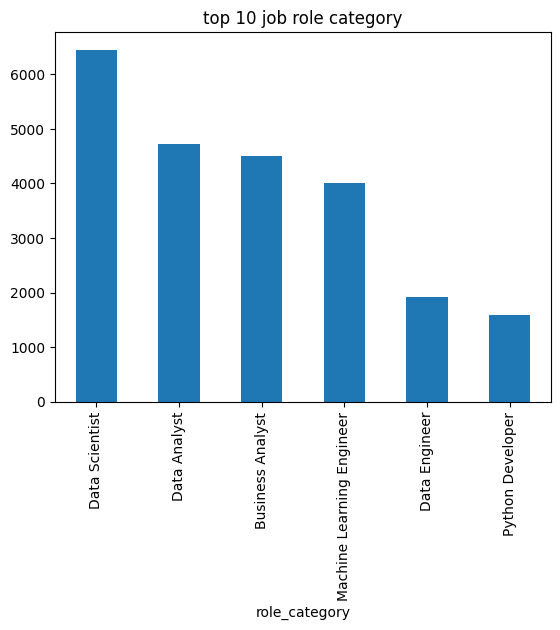

In [61]:
processed_data['role_category'].value_counts().head(10).plot(
kind='bar',
title='top 10 job role category'
)

<Axes: title={'center': 'Job Distribution by Work Mode'}, xlabel='work_mode'>

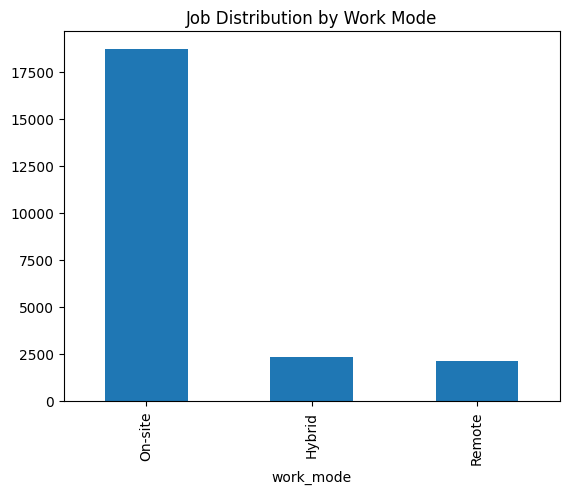

In [62]:
processed_data['work_mode'].value_counts().plot(
    kind='bar',
    title='Job Distribution by Work Mode'
)

<Axes: title={'center': 'Fresher-Friendly Jobs'}, xlabel='is_fresher_friendly'>

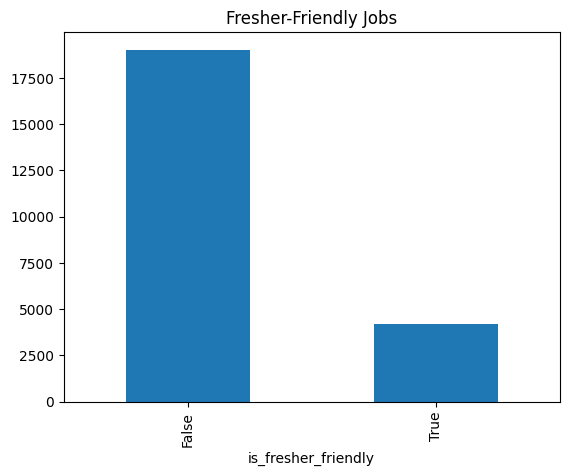

In [63]:
processed_data['is_fresher_friendly'].value_counts().plot(
    kind='bar',
    title='Fresher-Friendly Jobs'
)

<Axes: title={'center': 'Top 15 Skills in Job Postings'}, xlabel='skills'>

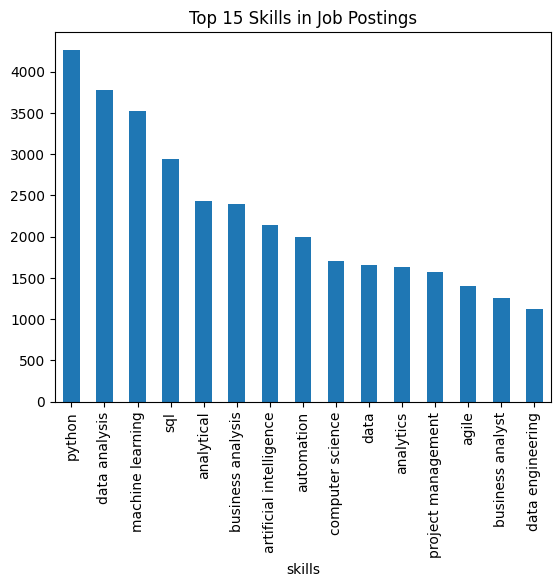

In [64]:
(
    processed_data['skills']
    .dropna()
    .explode()
    .value_counts()
).head(15).plot(
    kind='bar',
    title='Top 15 Skills in Job Postings'
)



<Axes: title={'center': 'Distribution of Days Since Posted'}, ylabel='Frequency'>

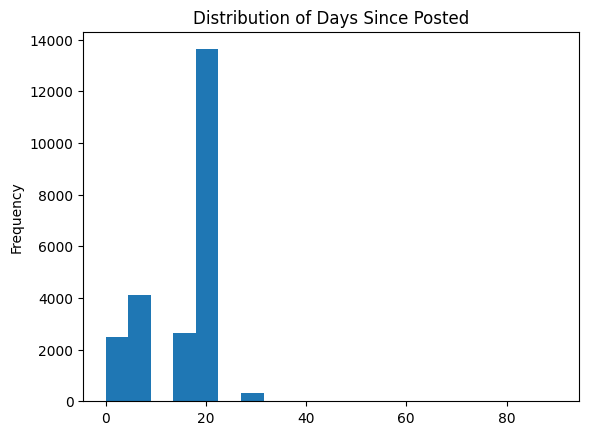

In [65]:
processed_data['days_since_posted'].plot(
    kind='hist',
    bins=20,
    title='Distribution of Days Since Posted'
)

## sklearn preprocessing

In [66]:
numerical_features = [
    'experience_min_yrs',
    'experience_max_yrs',
    'days_since_posted',
]

In [67]:
processed_data[numerical_features].isna().sum()

experience_min_yrs    0
experience_max_yrs    0
days_since_posted     0
dtype: int64

In [68]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler 


In [69]:
num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [70]:
num_data=num_pipeline.fit_transform(processed_data[numerical_features])

num_data.shape

(23201, 3)

In [71]:
categorical_features=['role_category','work_mode']

In [72]:
processed_data[categorical_features].isna().sum()

role_category    0
work_mode        0
dtype: int64

In [73]:
for col in categorical_features:
    print(col)
    print(processed_data[col].unique())
    print()

role_category
['Data Scientist' 'Data Analyst' 'Machine Learning Engineer'
 'Data Engineer' 'Business Analyst' 'Python Developer']

work_mode
['On-site' 'Hybrid' 'Remote']



In [74]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

In [75]:
cat_data=cat_pipeline.fit_transform(processed_data[categorical_features])

cat_data.shape

(23201, 9)

In [76]:
processed_data['skills'].explode().value_counts().head()

skills
python              4264
data analysis       3776
machine learning    3520
sql                 2940
analytical          2427
Name: count, dtype: int64

In [77]:
skill_aliases = {
    'ml': 'machine learning',
    'machine learning': 'machine learning',

    'ai': 'artificial intelligence',
    'artificial intelligence': 'artificial intelligence',

    'sklearn': 'scikit-learn',
    'scikit learn': 'scikit-learn',
    'scikit-learn': 'scikit-learn',

    'power bi': 'power bi',
    'powerbi': 'power bi',

    'ms excel': 'excel',
    'microsoft excel': 'excel',
    'excel': 'excel',

    'dl': 'deep learning',
    'power bi dashboards': 'power bi',
    'data scientist': 'data science',
    'containerization': 'docker'
}

In [78]:
def normalize_skill(skill):
    skill = skill.strip().lower()
    return skill_aliases.get(skill, skill)

In [79]:
processed_data['skills_normalized'] = processed_data['skills'].apply(
    lambda skills: [normalize_skill(skill) for skill in skills]
    if isinstance(skills, list) else skills
)

In [80]:
processed_data[['skills', 'skills_normalized']].head(10)

,skills,skills_normalized
0,"[computer science, data analysis, data science...","[computer science, data analysis, data science..."
1,"[basic, data management, business analytics, a...","[basic, data management, business analytics, a..."
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,"[supply chain, data science, aerospace, machin...","[supply chain, data science, aerospace, machin..."
8,"[product management, prototype, data science, ...","[product management, prototype, data science, ..."
9,"[python, data analysis, data domain, vertex, d...","[python, data analysis, data domain, vertex, d..."


In [81]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb=MultiLabelBinarizer()

In [82]:
skill_matrix=mlb.fit_transform(
    processed_data['skills_normalized'].apply(
        lambda x: x if isinstance(x, list) else []

    )
)
print(skill_matrix.shape)

(23201, 10625)


In [83]:
print(mlb.classes_[:50])

['. system architecture & design' '.net' '.net architecture' '.net core'
 '.net core c#' '.net core technologies' '.net core.' '.net developer'
 '.net development background' '.net framework' '.net software developer'
 '.net6' '.net8'
 '/ large-scale data processing sql data pipeline development' '0 to 1'
 '10635' '1099' '1d simulation' '26as' '277' '2d modeling'
 '32 bit microcontrollers' '3d' '3d animation' '3d animator'
 '3d annotation' '3d cad' '3d deep learning' '3d environment'
 '3d game development' '3d modeling' '3d printing' '3ds max' '3g'
 '3pl operations' '3pl solutions' '401k' '5 why' '5g' '5g core'
 '7+ years of backend development experience' '8090' '8d' '8d analysis'
 '999' 'a+' 'a/b experiment' 'a/b testing' 'aa' 'aac']


In [84]:
print(len(mlb.classes_))

10625


In [85]:
skill_counts = (
    processed_data['skills_normalized']
    .explode()
    .value_counts()
)

In [86]:
print(skill_counts.head(20))

skills_normalized
python                     4264
machine learning           3785
data analysis              3776
sql                        2940
artificial intelligence    2855
analytical                 2427
business analysis          2396
automation                 1995
computer science           1699
data                       1654
analytics                  1636
project management         1573
agile                      1401
business analyst           1251
data science               1126
power bi                   1120
data engineering           1118
gcp                        1061
data modeling              1057
data quality               1041
Name: count, dtype: int64


In [87]:
print((skill_counts == 1).sum())

4974


In [88]:
common_skills = skill_counts[skill_counts >= 5].index

print(len(common_skills))

2779


In [89]:
processed_data['skills_filtered']=processed_data['skills_normalized'].apply(
    lambda skills: [
        skill for skill in skills 
        if skill in common_skills
    ]
    if isinstance(skills, list) else []
)

In [90]:
print(processed_data['skills_filtered'].head())

0    [computer science, data analysis, data science...
1    [basic, data management, business analytics, a...
2                                                   []
3                                                   []
4                                                   []
Name: skills_filtered, dtype: object


In [91]:
from sklearn.preprocessing import MultiLabelBinarizer

skill_mlb = MultiLabelBinarizer()

skill_matrix = skill_mlb.fit_transform(
    processed_data['skills_filtered']
)

print(skill_matrix.shape)

(23201, 2779)


In [92]:
processed_data['job_description_clean'].isna().sum()

np.int64(404)

In [93]:
processed_data['job_description_clean']=(processed_data['job_description_clean'].fillna(''))

In [94]:
processed_data['job_description_clean'].isna().sum()

np.int64(0)

In [95]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1,2)
)

tfidf_matrix=tfidf.fit_transform(processed_data['job_description_clean'])

In [96]:
tfidf_matrix.shape

(23201, 5000)

## We'll calculate three main things:

1. Skill similarity → Does the candidate have the required skills?
2. Text similarity → How similar is the resume to the job description?
3. Preference/compatibility → Role, location, work mode, experience, etc.

1. Create resume-processing file
        ↓
2. Extract text from PDF
        ↓
3. Clean extracted text
        ↓
4. Extract candidate skills
        ↓
5. Normalize skills
        ↓
6. Create Candidate Profile

In [97]:
common_skills

Index(['python', 'machine learning', 'data analysis', 'sql',
       'artificial intelligence', 'analytical', 'business analysis',
       'automation', 'computer science', 'data',
       ...
       'data science tools', 'financial reconciliation', 'successfactors',
       'facilities', 'partnership management', 'scale', 'raw material',
       'sql tuning', 'sap pi po', 'llb'],
      dtype='object', name='skills_normalized', length=2779)

In [98]:
import json

with open("../data/common_skills.json", "w") as f:
    json.dump(list(common_skills), f)

In [99]:
skill_matrix

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(23201, 2779))

In [100]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

skill_matrix = mlb.fit_transform(
    processed_data["skills_filtered"]
)

print("MLB classes:", len(mlb.classes_))
print("Skill matrix shape:", skill_matrix.shape)

MLB classes: 2779
Skill matrix shape: (23201, 2779)


In [101]:
import json 

with open("../data/candidate_profile.json","r") as f:
    candidate_profile=json.load(f)

candidate_skills=candidate_profile["skills"]
print(candidate_skills)

['python', 'machine learning', 'sql', 'power bi', 'aws', 'excel', 'git', 'linux', 'deployment', 'tensorflow', 'github', 'docker', 'pytorch', 'numpy', 'scikit-learn', 'pandas', 'nlp', 'fastapi', 'openai', 'matplotlib', 'nltk']


In [102]:
candidate_vector=mlb.transform([candidate_skills])

candidate_vector.shape

(1, 2779)

In [103]:
from sklearn.metrics.pairwise import cosine_similarity

skill_scores=cosine_similarity(candidate_vector, skill_matrix).flatten()

print("Skill scores shape:", skill_scores.shape)
print("First 10 scores:", skill_scores[:10])

Skill scores shape: (23201,)
First 10 scores: [0.         0.07715167 0.         0.         0.         0.
 0.         0.15430335 0.07715167 0.15430335]


In [104]:
processed_data["skill_match_score"]=skill_scores

In [105]:
processed_data[
        ["job_title", "company_name", "skill_match_score"]
    ].head()

,job_title,company_name,skill_match_score
0,Data Scientist,Cisco,0.000000
1,Data Scientist,Caterpillar Inc,0.077152
2,Analytics Data Scientist,Foreign IT Consulting MNC,0.000000
3,Data Scientist,Fortune 500 IT Services Company,0.000000
4,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,0.000000


In [106]:
top_skill_jobs=processed_data.nlargest(10,"skill_match_score")[[
    "job_id",
    "job_title",
    "company_name",
    "skills_required",
    "skill_match_score"
]]

top_skill_jobs.head()

,job_id,job_title,company_name,skills_required,skill_match_score
3554,3555,Senior Analyst - Data Science,LatentView,"python, lending, scikit-learn, power bi, numpy...",0.540062
2686,2687,Senior Data Scientist (Fintech),HT Digital Streams,"Python, Pytorch, bureau data, Artificial Intel...",0.494872
4614,4615,SE/SSE/ML-AI (Search),Bold Technology Systems,"Machine Learning, Python, Nltk, Tensorflow, Py...",0.487950
2666,2667,Data Scientist-Advanced Analytics,IBM,"data scientist, python, github, predictive ana...",0.462910
3304,3305,Data Scientist,NOVAC,"Django, Machine Learning, Python, pandas, Micr...",0.462910


In [107]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 245716 stored elements and shape (23201, 5000)>

In [108]:
with open("../data/candidate_profile.json","r") as f:
    candidate_profile=json.load(f)

In [109]:
import pymupdf
document=pymupdf.open("../resumes/deepika_compressed.pdf")

resume_text=""
for page in document:
    resume_text += page.get_text()

document.close()

print(resume_text[:1000])

 
DEEPIKA SAINI 
Computer Science Student | Data Scientist & ML Enthusiast 
Jaipur, India | 📧 dipseek5@gmail.com |+917375914122 |🔗linkedin.com/in/deepika-ajmera | 💻github.com/dipseek  
 
 
PROFESSIONAL SUMMARY 
Computer Science student specializing in Data Science and Machine Learning. Skilled in Python, SQL, ML/DL 
models, NLP, and deploying solutions with FastAPI, Docker, AWS, and visualization dashboards. 
 
TECHNICAL SKILLS 
➢ Programming: Python, SQL, Pandas, NumPy 
➢ Machine Learning: TensorFlow, Scikit-Learn, NLP, PyTorch 
➢ Data Tools: Power BI, Excel, Matplotlib, Seaborn 
➢ API Integration: FastAPI 
➢ Tools: AWS(Deployment), Docker, Git, GitHub, Linux 
 
PROJECTS 
Insurance Premium Prediction API 
• 
Built and deployed insurance premium prediction API with FastAPI. 
• 
Containerized with Docker, pushed to DockerHub, and tested by pulling image. 
• 
Tools: FastAPI, Docker, DockerHub, Python, Scikit-learn 
Personalized Movie Recommendation System 
• 
Developed recommendation eng

In [110]:
candidate_tfidf=tfidf.transform([resume_text])
candidate_tfidf.shape

(1, 5000)

In [111]:
from sklearn.metrics.pairwise import cosine_similarity

text_scores=cosine_similarity(candidate_tfidf, tfidf_matrix).flatten()

print("Text scores shape:", text_scores.shape)
print("First 10 scores:", text_scores[:10])

Text scores shape: (23201,)
First 10 scores: [0.06866514 0.07717865 0.         0.         0.         0.
 0.         0.0054471  0.03343019 0.00334914]


In [112]:
processed_data['text_similarity_score']=text_scores
print(processed_data[['job_title','company_name','text_similarity_score']].head())

                              job_title                     company_name  \
0                        Data Scientist                            Cisco   
1                        Data Scientist                  Caterpillar Inc   
2              Analytics Data Scientist        Foreign IT Consulting MNC   
3                        Data Scientist  Fortune 500 IT Services Company   
4  Sr. Artificial Intelligence Engineer    Fortune 500 Product-based MNC   

   text_similarity_score  
0               0.068665  
1               0.077179  
2               0.000000  
3               0.000000  
4               0.000000  


In [113]:
top_text_jobs=processed_data.nlargest(10,"text_similarity_score")[["job_id",
        "job_title",
        "company_name",
        "text_similarity_score"]]

top_text_jobs

,job_id,job_title,company_name,text_similarity_score
330,331,Senior Data Scientist,Wipro,0.378334
1805,1806,Senior Data Scientist,Wipro,0.378334
565,566,Manager -Data Scientist,Mindshare,0.366331
575,576,Manager -Data Scientist,Mindshare,0.366331
4681,4682,Manager -Data Scientist,Mindshare,0.366331
610,611,Data Scientist - 2,Satsure Analytics,0.355478
572,573,"Data Science Manager, data scientist",Abinbev Gcc Services,0.352755
7839,7840,Associate Software Analyst,PTC,0.352297
5339,5340,Soc Analyst,Calsoft,0.339527
11196,11197,Machine Learning Engineer ( RAG & Generative AI),Experis,0.338461


In [114]:
candidate_experience=0
def experience_score(min_exp,max_exp):

    if min_exp<=candidate_experience<=max_exp:
        return 1
    else:
        return 0

processed_data["experience_score"]=processed_data.apply(lambda row: experience_score(row['experience_min_yrs'],row['experience_max_yrs']),axis=1)

print(processed_data[['job_title','experience_min_yrs','experience_max_yrs','experience_score']].head(10))

                              job_title  experience_min_yrs  \
0                        Data Scientist                 7.0   
1                        Data Scientist                 4.0   
2              Analytics Data Scientist                 4.0   
3                        Data Scientist                 0.0   
4  Sr. Artificial Intelligence Engineer                 5.0   
5                        Data Scientist                 3.0   
6                        Data Scientist                 5.0   
7               Advanced Data Scientist                 5.0   
8  Data Scientist, Google Play, Product                 5.0   
9       Machine Learning Data Scientist                 3.0   

   experience_max_yrs  experience_score  
0                10.0                 0  
1                 8.0                 0  
2                 9.0                 0  
3                 0.0                 1  
4                10.0                 0  
5                 8.0                 0  
6           

In [115]:
## create seniority score

import numpy as np

def seniority_score(job_title):
    title=job_title.lower()

    if any(word in title for word in [
        "senior","sr.","lead","manager","principal","director","head"
    ]):
        return 0.2

    elif any(word in title for word in [
        "trainee","intern","junior","associate","fresher"
    ]):
        return 1.0

    else:
        return 0.8

In [116]:
processed_data["seniority_score"]=(processed_data['job_title'].fillna("").apply(seniority_score))

## calculating final match score

In [117]:
processed_data["final_match_score"]=(0.50*processed_data['skill_match_score']
                                     + 0.30*processed_data['text_similarity_score']
                                     + 0.05*processed_data['experience_score']
                                     + 0.15*processed_data['seniority_score'])


In [118]:
print(processed_data[['job_title','skill_match_score','text_similarity_score','experience_score','seniority_score','final_match_score']])

                                             job_title  skill_match_score  \
0                                       Data Scientist           0.000000   
1                                       Data Scientist           0.077152   
2                             Analytics Data Scientist           0.000000   
3                                       Data Scientist           0.000000   
4                 Sr. Artificial Intelligence Engineer           0.000000   
...                                                ...                ...   
23196                       Python Developer-Hyderabad           0.356348   
23197                                 Python Developer           0.077152   
23198  Walk in Interview Python Developer II Hyderabad           0.195180   
23199                                 Python Developer           0.154303   
23200                                 Python Developer           0.089087   

       text_similarity_score  experience_score  seniority_score  \
0       

In [119]:
top_jobs=processed_data.nlargest(10, "final_match_score")[['job_id','job_title','company_name','location_clean','work_mode','experience_min_yrs','experience_max_yrs','skill_match_score','text_similarity_score','experience_score','seniority_score','final_match_score']]

In [120]:
top_jobs

,job_id,job_title,company_name,location_clean,work_mode,experience_min_yrs,experience_max_yrs,skill_match_score,text_similarity_score,experience_score,seniority_score,final_match_score
7839,7840,Associate Software Analyst,PTC,[Pune],On-site,0.0,3.0,0.247436,0.352297,1,1.0,0.429407
4275,4276,Machine Learning Engineer,Leading Client,"[Noida, Hyderabad, Bengaluru]",On-site,3.0,8.0,0.385758,0.265189,0,0.8,0.392436
12054,12055,Machine Learning Engineer,Leading Client,"[Hyderabad, Noida, Bengaluru]",On-site,3.0,8.0,0.385758,0.265189,0,0.8,0.392436
4614,4615,SE/SSE/ML-AI (Search),Bold Technology Systems,[Noida],Hybrid,3.0,6.0,0.487950,0.087475,0,0.8,0.390217
315,316,Python Developer cum Data Scientist,Hiring for one of the Big4 Company,[Bengaluru],Hybrid,5.0,9.0,0.462910,0.108625,0,0.8,0.384043
6907,6908,Business Analyst III,Amazon,[Bengaluru],On-site,0.0,0.0,0.377964,0.061126,1,0.8,0.377320
330,331,Senior Data Scientist,Wipro,"[Hyderabad, Pune, Bengaluru]",Hybrid,6.0,11.0,0.462910,0.378334,0,0.2,0.374955
1805,1806,Senior Data Scientist,Wipro,"[Pune, Hyderabad, Bengaluru]",Hybrid,6.0,11.0,0.462910,0.378334,0,0.2,0.374955
9155,9156,AI Workflow Trainee,Shipgig Ventures,[Noida],On-site,0.0,0.0,0.308607,0.050843,1,1.0,0.369556
15443,15444,Data Engineer - Python Backend,Krazy Bee Services,[Bengaluru],On-site,2.0,4.0,0.462910,0.058291,0,0.8,0.368942


## skill gap analysis

In [121]:
candidate_skill_set=set(candidate_skills)
candidate_skill_set

{'aws',
 'deployment',
 'docker',
 'excel',
 'fastapi',
 'git',
 'github',
 'linux',
 'machine learning',
 'matplotlib',
 'nlp',
 'nltk',
 'numpy',
 'openai',
 'pandas',
 'power bi',
 'python',
 'pytorch',
 'scikit-learn',
 'sql',
 'tensorflow'}

In [122]:
ignore_gap_skills = {
    "data",
    "data science",
    "analysis",
    "computer science"
}

skill_gap_aliases = {
    "fast api": "fastapi",
    "natural language processing": "nlp",
    "natural-language processing": "nlp",
    "data science": "data science",
    "artificial intelligence": "artificial intelligence"
}

In [123]:
def get_skill_gap(job_skills):
    normalized_job_skills={
        skill_gap_aliases.get(skill,skill)
        for skill in job_skills
        if skill not in ignore_gap_skills
    }
    normalized_candidate_skills={
        skill_gap_aliases.get(skill,skill)
        for skill in candidate_skills
        if skill not in ignore_gap_skills
    }

    matched = normalized_job_skills & normalized_candidate_skills
    missing = normalized_job_skills - normalized_candidate_skills

    return sorted(matched), sorted(missing)

In [124]:
top_jobs=processed_data.nlargest(10, "final_match_score").copy()
top_jobs[["job_id", "job_title", "company_name"]]

,job_id,job_title,company_name
7839,7840,Associate Software Analyst,PTC
4275,4276,Machine Learning Engineer,Leading Client
12054,12055,Machine Learning Engineer,Leading Client
4614,4615,SE/SSE/ML-AI (Search),Bold Technology Systems
315,316,Python Developer cum Data Scientist,Hiring for one of the Big4 Company
6907,6908,Business Analyst III,Amazon
330,331,Senior Data Scientist,Wipro
1805,1806,Senior Data Scientist,Wipro
9155,9156,AI Workflow Trainee,Shipgig Ventures
15443,15444,Data Engineer - Python Backend,Krazy Bee Services


In [125]:
top_jobs[["matched_skills","missing_skills"]]=top_jobs["skills_filtered"].apply(lambda x:get_skill_gap(x)).apply(pd.Series)

In [126]:
top_jobs[
    [
        "job_title",
        "company_name",
        "matched_skills",
        "missing_skills"
    ]
]

,job_title,company_name,matched_skills,missing_skills
7839,Associate Software Analyst,PTC,"[docker, machine learning, sql]","[algorithms, artificial intelligence, nosql, s..."
4275,Machine Learning Engineer,Leading Client,"[machine learning, nlp, python, pytorch, sciki...","[aws sagemaker, deep learning, mlops]"
12054,Machine Learning Engineer,Leading Client,"[machine learning, nlp, python, pytorch, sciki...","[aws sagemaker, deep learning, mlops]"
4614,SE/SSE/ML-AI (Search),Bold Technology Systems,"[machine learning, nltk, python, pytorch, tens...",[]
315,Python Developer cum Data Scientist,Hiring for one of the Big4 Company,"[fastapi, machine learning, numpy, python, sci...",[al]
6907,Business Analyst III,Amazon,"[aws, python, sql]",[]
330,Senior Data Scientist,Wipro,"[aws, pandas, python, pytorch, scikit-learn, t...",[]
1805,Senior Data Scientist,Wipro,"[aws, pandas, python, pytorch, scikit-learn, t...",[]
9155,AI Workflow Trainee,Shipgig Ventures,"[machine learning, nlp, numpy, python, scikit-...","[artificial intelligence, c++, problem solving]"
15443,Data Engineer - Python Backend,Krazy Bee Services,"[aws, fastapi, machine learning, nlp, python, ...",[]


## explainability

In [127]:
candidate_experience=0

def experience_explanation(row):
    min_exp=row["experience_min_yrs"]
    max_exp=row["experience_max_yrs"]

    if candidate_experience < min_exp:
        return f"Experience mismatch: candidate has {candidate_experience} years; job requires {min_exp:.0f}-{max_exp:.0f} years."

    elif candidate_experience > max_exp:
        return f"Candidate exceeds the stated experience range of {min_exp:.0f}-{max_exp:.0f} years."

    else:
        return "Experience requirement matches the candidate."

In [128]:
def explain_job(row):

    explaination={
        "job_title": row["job_title"],
        "company": row["company_name"],
        "match_score": round(row["final_match_score"],3),
        "skill_score": round(row["skill_match_score"],3),
        "text_score": round(row["text_similarity_score"],3),
        "experience": experience_explanation(row),
        "matched_skills": row['matched_skills'],
        "missing_skills": row['missing_skills']
    }
    return explaination

In [129]:
explainations=top_jobs.apply(explain_job,axis=1).tolist()
explainations[:2]

[{'job_title': 'Associate Software Analyst',
  'company': 'PTC',
  'match_score': 0.429,
  'skill_score': 0.247,
  'text_score': 0.352,
  'experience': 'Experience requirement matches the candidate.',
  'matched_skills': ['docker', 'machine learning', 'sql'],
  'missing_skills': ['algorithms',
   'artificial intelligence',
   'nosql',
   'software']},
 {'job_title': 'Machine Learning Engineer',
  'company': 'Leading Client',
  'match_score': 0.392,
  'skill_score': 0.386,
  'text_score': 0.265,
  'experience': 'Experience mismatch: candidate has 0 years; job requires 3-8 years.',
  'matched_skills': ['machine learning',
   'nlp',
   'python',
   'pytorch',
   'scikit-learn'],
  'missing_skills': ['aws sagemaker', 'deep learning', 'mlops']}]

In [130]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(tfidf, "../models/tfidf.pkl")
joblib.dump(mlb, "../models/mlb.pkl")
joblib.dump(processed_data,"../models/processed_data.pkl")

print("Models and processed jobs saved")

Models and processed jobs saved


In [131]:
joblib.dump(skill_matrix,"../models/skill_matrix.pkl")
joblib.dump(tfidf_matrix,"../models/tfidf_matrix.pkl")

print("done")

done
